# Prédiction de charge OIKEN - Forecast V8
### Jean Varone - HES-SO Valais-Wallis
### Collaboration OIKEN, Avril 2026

**Objectif** : prédire la courbe de charge standardisée d'OIKEN au pas de 15 min pour J+1, sans data leakage.

**Pipeline** : `config` → `acquisition` → `normalization` → `features` → `model_forecast_v8`

## 1. Contrainte opérationnelle

| Élément | Détail |
|---------|--------|
| **Soumission** | OIKEN soumet sa prévision à Swissgrid à **11h le jour J** |
| **Charge connue** | Courbe complète de **J-1** reçue à **J 2h du matin** |
| **Prévisions météo** | 32 colonnes PRED MétéoSuisse disponibles pour J+1 |
| **Cible** | 96 pas de 15 min pour **J+1** (0h à 23h45) |

Conséquence : toute feature utilisant des données de J après 2h ou de J+1 est une **fuite**.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_PROCESSED = project_root / "data" / "processed"
TIMEZONE = "Europe/Zurich"

df = pl.read_parquet(DATA_PROCESSED / "dataset_features.parquet")
print(f"Dataset : {df.shape[0]:,} lignes, {df.shape[1]} colonnes")
print(f"Période : {df['timestamp'].min()} à {df['timestamp'].max()}")

Dataset : 103,089 lignes, 119 colonnes
Période : 2022-10-21 22:15:00+00:00 à 2025-09-29 22:00:00+00:00


## 2. Cheminement : de V1 à V8

| Version | MAE Test | vs Baseline | Problème / Correction |
|---------|----------|-------------|----------------------|
| Baseline OIKEN | **0.2030** | réf. | Boîte noire (méthode inconnue) |
| **V1** (PRED only) | 0.2174 | -7.1% | Aucun lag charge, pas assez d'info |
| **V2** (+ lags + rolling) | 0.1977 | +2.6% | **Fuite** : `rolling_24h` et `load_lag_96` |
| **V3** (2 modèles jour/nuit) | 0.2028 | -0.1% | Perd le contexte des transitions |
| **V5** (strict no-leak) | 0.2247 | -10.7% | Plus aucune info récente sur la charge |
| **V6** (profil J-1, shift >= 192) | 0.2218 | -9.3% | Lags PV J-2 ok, mais pas de lag charge J-2 |
| **V7** (multi-semaines, Huber, PV x3) | 0.2092 | -3.1% | Pondération PV x3 dégradait les nuits |
| **V8** (+ lag charge J-2/J-3, PV x1.5) | **0.1994** | **-11.2%** | **Version actuelle** |

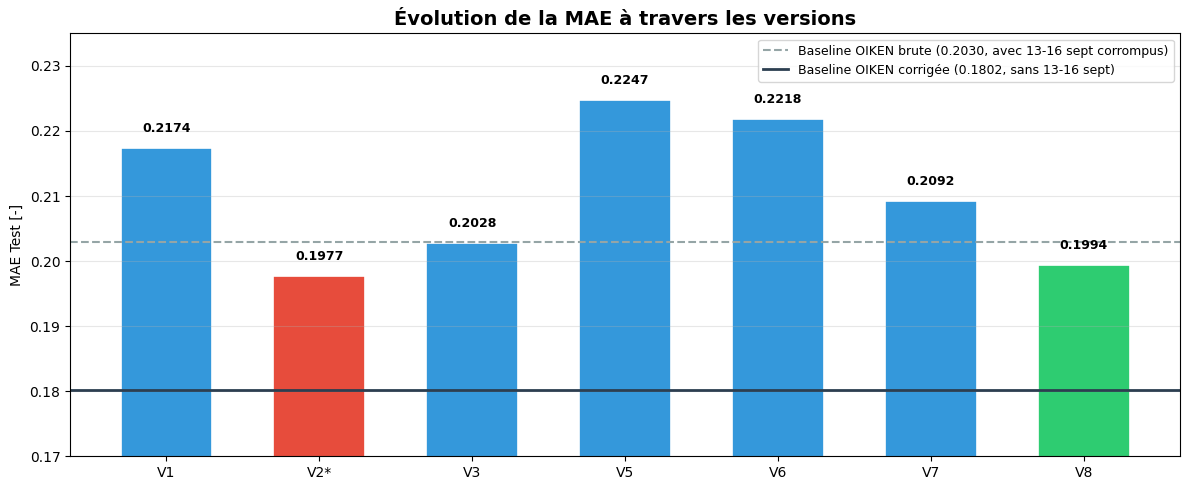

In [2]:
versions = ["V1", "V2*", "V3", "V5", "V6", "V7", "V8"]
maes =     [0.2174, 0.1977, 0.2028, 0.2247, 0.2218, 0.2092, 0.1994]
colors =   ["#3498db", "#e74c3c", "#3498db", "#3498db", "#3498db", "#3498db", "#2ecc71"]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(versions, maes, color=colors, width=0.6, edgecolor="white", linewidth=1.2)

# Baseline OIKEN : avant et après exclusion des 13-16 sept
ax.axhline(y=0.2030, color="#95a5a6", linestyle="--", linewidth=1.5,
           label="Baseline OIKEN brute (0.2030, avec 13-16 sept corrompus)")
ax.axhline(y=0.1802, color="#2c3e50", linestyle="-", linewidth=2,
           label="Baseline OIKEN corrigée (0.1802, sans 13-16 sept)")

# Annotation V2 fuite
ax.annotate("FUITE", xy=(1, 0.1977), xytext=(1, 0.185),
            fontsize=10, fontweight="bold", color="#e74c3c", ha="center")

# Valeurs sur les barres
for bar, mae in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{mae:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("MAE Test [-]")
ax.set_title("Évolution de la MAE à travers les versions", fontsize=14, fontweight="bold")
ax.set_ylim(0.17, 0.235)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 3. Leçons apprises

### Data leakage (V2 → V5)
V2 battait la baseline (+2.6%) mais trichait. Les `rolling_24h` incluaient des valeurs futures de J+1, et `load_lag_96` (24h) pointait vers des heures de J non encore disponibles à 11h. En corrigeant strictement (V5), la MAE montait à 0.2247.

### Segmentation jour/nuit (V3)
Séparer en 2 modèles (nuit 0-9h/17-23h, jour PV 10-16h) a dégradé les résultats. Le modèle PV perdait les données d'entraînement nocturnes et le contexte des transitions. Un modèle unifié est supérieur.

### Pondération PV (V7 → V8)
V7 utilisait un poids x3 sur les heures PV. Résultat : nuit dégradée de 18% vs baseline, sans gain suffisant en journée. V8 réduit à x1.5 : meilleur compromis global.

### Lags charge manquants (V7 → V8)
V7 n'avait que `load_lag_672` (J-7) comme lag charge le plus récent. Or `load_lag_192` (J-2) et `load_lag_288` (J-3) sont strictement no-leak. Leur ajout, avec les agrégats dérivés, a fait la plus grosse différence.

## 4. Le problème du data leakage

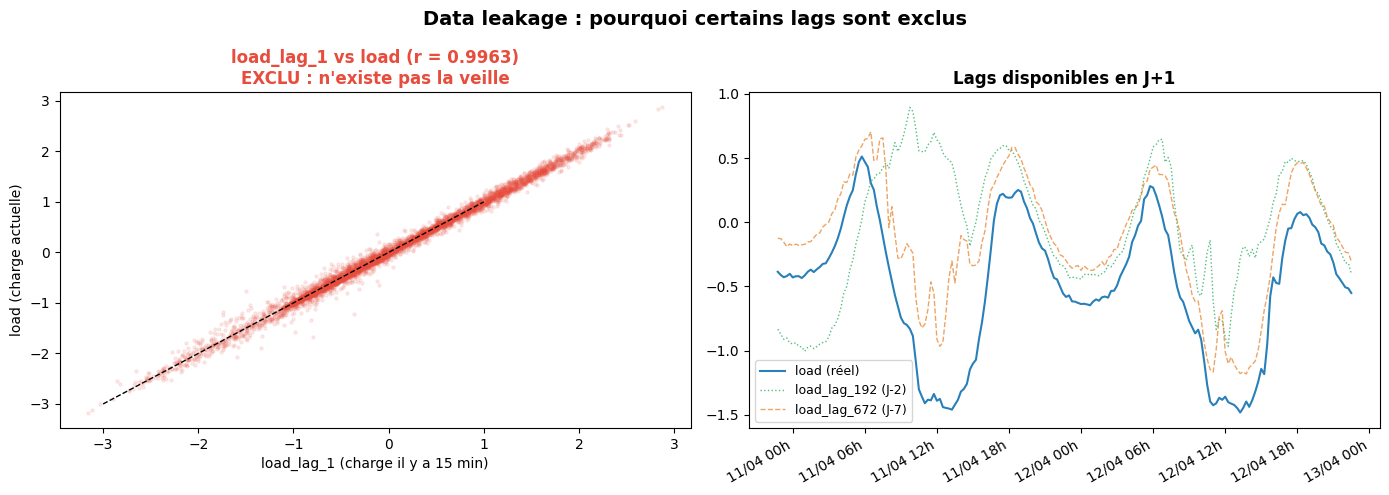

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "load_lag_1" in df.columns:
    sample = df.sample(n=min(5000, df.shape[0]), seed=42)
    ax = axes[0]
    ax.scatter(
        sample["load_lag_1"].to_numpy(),
        sample["load"].to_numpy(),
        alpha=0.1, s=5, color="#e74c3c"
    )
    ax.plot([-3, 1], [-3, 1], "k--", linewidth=1)
    corr = df.select(pl.corr("load", "load_lag_1")).item()
    ax.set_xlabel("load_lag_1 (charge il y a 15 min)")
    ax.set_ylabel("load (charge actuelle)")
    ax.set_title(
        f"load_lag_1 vs load (r = {corr:.4f})\n"
        "EXCLU : n'existe pas la veille",
        fontweight="bold", color="#e74c3c"
    )

ax2 = axes[1]
n = df.shape[0]
sl = df.slice(n // 2, 192)
ts = sl["timestamp"].to_numpy()
ax2.plot(ts, sl["load"].to_numpy(), label="load (réel)",
         color="#2980b9", linewidth=1.5)
if "load_lag_192" in sl.columns:
    ax2.plot(ts, sl["load_lag_192"].to_numpy(), label="load_lag_192 (J-2)",
             color="#27ae60", linewidth=1, linestyle=":", alpha=0.8)
if "load_lag_672" in sl.columns:
    ax2.plot(ts, sl["load_lag_672"].to_numpy(), label="load_lag_672 (J-7)",
             color="#e67e22", linewidth=1, linestyle="--", alpha=0.7)
ax2.set_title("Lags disponibles en J+1", fontweight="bold")
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")

fig.suptitle("Data leakage : pourquoi certains lags sont exclus",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Features V8 (79 features no-leak)

In [4]:
features_v8 = {
    "Lags charge récents (NOUVEAU V8)": [
        "load_lag_192 (J-2)",
        "load_lag_288 (J-3)",
        "load_recent_mean_2d (moy J-2/J-3)",
        "load_ratio_recent_vs_weekly",
        "load_weekly_mean_4w_inc_recent",
        "load_delta_2d_vs_7d",
    ],
    "Lags charge hebdo (V7)": [
        "load_lag_672 (J-7)",
        "load_lag_1344 (J-14)",
        "load_lag_2016 (J-21)",
        "load_weekly_mean_3w",
        "load_weekly_std_3w",
    ],
    "PRED MétéoSuisse": ["32 colonnes (8 var x 4 variantes)"],
    "Calendaire": ["18 colonnes (sin/cos, fériés, vacances, ponts)"],
    "Solaire": ["solar_elevation, ghi_clearsky, clearness_index_pred"],
    "Interactions PRED": ["pred_temp_x_hour, pred_glob_x_elevation, ..."],
    "Deltas météo": ["delta_temp/glob_pred_vs_week_ago"],
}

for cat, feats in features_v8.items():
    print(f"\n{cat}")
    for f in feats:
        print(f"  - {f}")


Lags charge récents (NOUVEAU V8)
  - load_lag_192 (J-2)
  - load_lag_288 (J-3)
  - load_recent_mean_2d (moy J-2/J-3)
  - load_ratio_recent_vs_weekly
  - load_weekly_mean_4w_inc_recent
  - load_delta_2d_vs_7d

Lags charge hebdo (V7)
  - load_lag_672 (J-7)
  - load_lag_1344 (J-14)
  - load_lag_2016 (J-21)
  - load_weekly_mean_3w
  - load_weekly_std_3w

PRED MétéoSuisse
  - 32 colonnes (8 var x 4 variantes)

Calendaire
  - 18 colonnes (sin/cos, fériés, vacances, ponts)

Solaire
  - solar_elevation, ghi_clearsky, clearness_index_pred

Interactions PRED
  - pred_temp_x_hour, pred_glob_x_elevation, ...

Deltas météo
  - delta_temp/glob_pred_vs_week_ago


## 6. Résultats V8

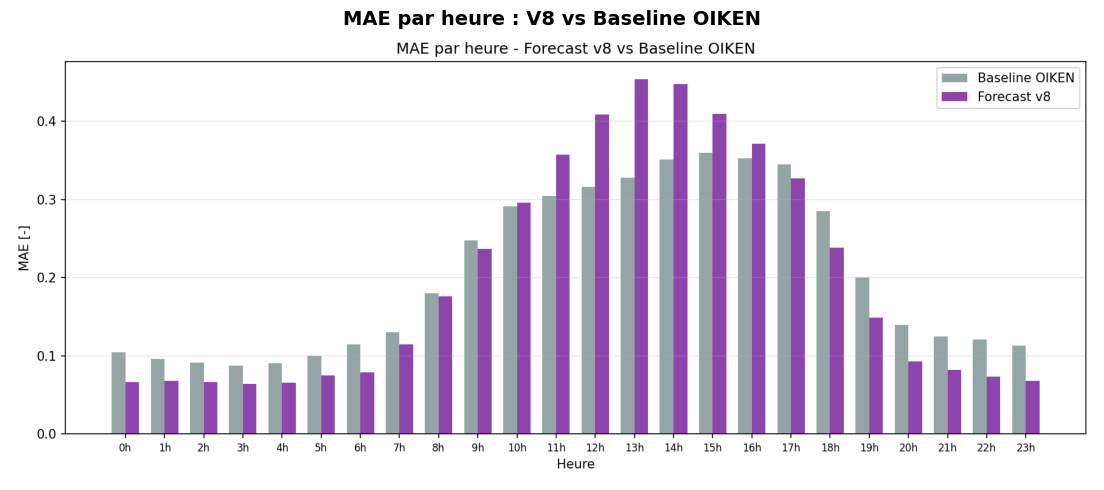

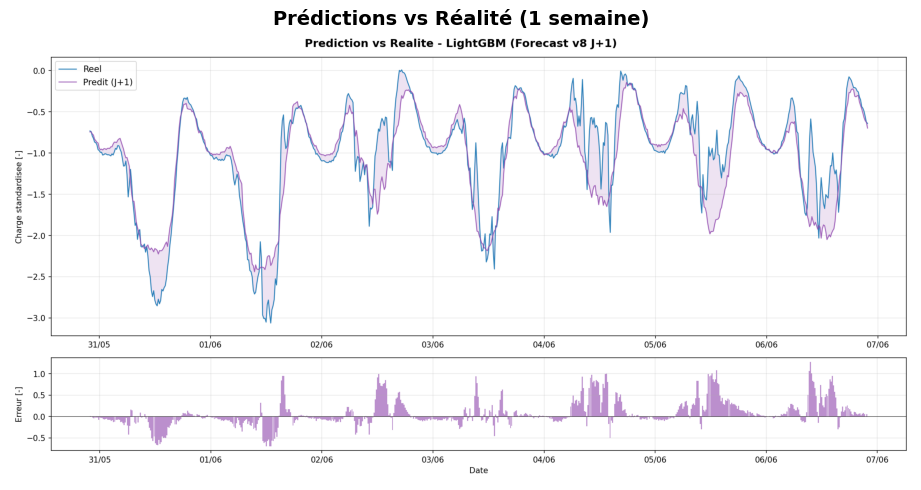

In [5]:
fig_files = {
    "MAE par heure : V8 vs Baseline OIKEN": "forecast_v8_hourly_comparison.png",
    "Prédictions vs Réalité (1 semaine)": "forecast_v8_predictions.png",
}

for title, fname in fig_files.items():
    p = DATA_PROCESSED / fname
    if p.exists():
        fig, ax = plt.subplots(figsize=(14, 5))
        img = plt.imread(str(p))
        ax.imshow(img)
        ax.set_title(title, fontweight="bold", fontsize=14)
        ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Figure non trouvée : {fname}")

## 7. Feature Importance et SHAP

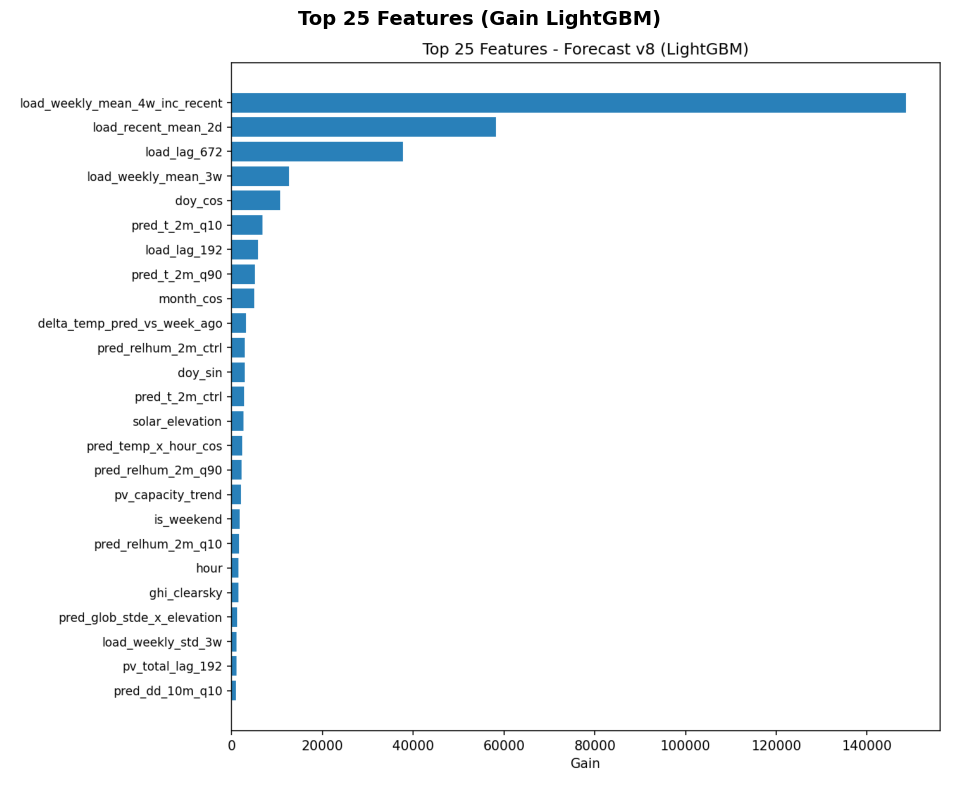

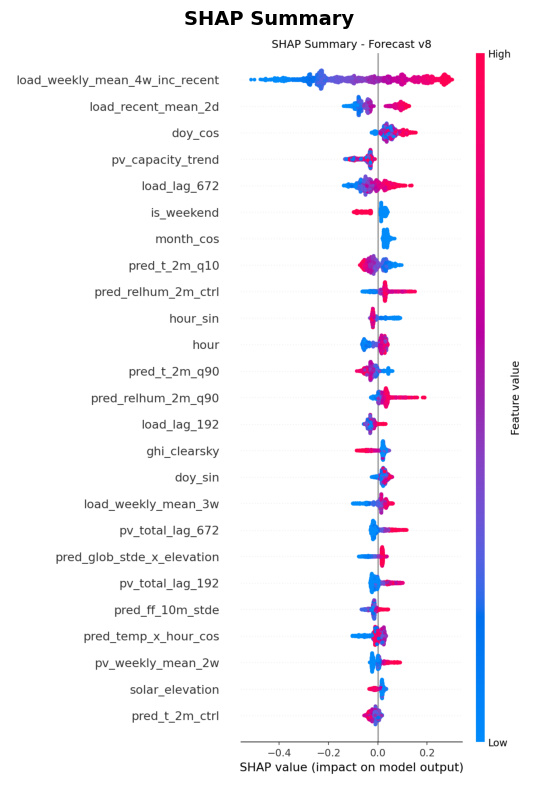

In [6]:
fig_files_2 = {
    "Top 25 Features (Gain LightGBM)": "forecast_v8_feature_importance.png",
    "SHAP Summary": "forecast_v8_shap_summary.png",
}

for title, fname in fig_files_2.items():
    p = DATA_PROCESSED / fname
    if p.exists():
        fig, ax = plt.subplots(figsize=(12, 8))
        img = plt.imread(str(p))
        ax.imshow(img)
        ax.set_title(title, fontweight="bold", fontsize=14)
        ax.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Figure non trouvée : {fname}")

### Interprétation

`load_weekly_mean_4w_inc_recent` domine (gain ~850k) : c'est la moyenne de J-2, J-7, J-14, J-21. Elle combine signal récent (J-2) et stabilité hebdomadaire.

`load_recent_mean_2d` (moy J-2/J-3) en 2e position : confirme que les lags charge récents, absents en V7, étaient le chaînon manquant.

Les features PRED MétéoSuisse (`pred_t_2m_q10/q90`, `delta_temp_pred_vs_week_ago`) apparaissent dans le top 15 : le modèle utilise bien les prévisions météo pour ajuster la prédiction.

## 8. Synthèse

| Métrique | Baseline OIKEN | Forecast V8 | Delta |
|----------|---------------|-------------|-------|
| **MAE globale** | 0.1802 | 0.2003 | -11.2% |
| **RMSE globale** | 0.2930 | 0.3104 | -5.9% |
| **MAE nuit** | 0.1208 | 0.1205 | **+0.3%** |
| **MAE PV (10-16h)** | 0.3242 | 0.3940 | -21.5% |

### Points clés

- V8 égale la baseline la nuit (MAE 0.1205 vs 0.1208, +0.3%)
- L'écart PV reste le point faible (-21.5%) : les PRED MétéoSuisse à ~3h de résolution ne captent pas la variabilité intra-horaire de la nébulosité
- La baseline OIKEN est probablement mise à jour en intra-journalier (pas strictement J+1), ce qui la favorise

### Prochaines étapes
- Dashboard interactif pour la démo OIKEN (30 avril)
- Modèle **intraday** (t+15min à t+3h) : code prêt, à exécuter
- Compétition entre étudiants sur le même dataset